# Fibered Barcode

For $M:P\to\mathrm{Vect}_k$, basepoint $b\in\mathbb R^n$, and strictly
positive direction $v\in\mathbb R^n_{>0}$, define the affine line restriction

$$
M^\ell_t=M_{\ell(t)},\qquad \ell(t)=b+t v.
$$

Since every coordinate of $v$ is positive, $t\le s$ implies
$\ell(t)\le\ell(s)$, so $M^\ell$ is an ordinary 1-parameter persistence module.
`fibered_barcode` returns $\mathcal B(M^\ell)$ for one line;
`fibered_barcodes` evaluates several lines. The same line restrictions are
used by the [matching-distance notebook](../distances/matching_distance.ipynb).

In [1]:
import numpy as np

import matplotlib.pylab as plt
import multipers as mp
import multipers.invariants as mpi
from sklearn.datasets import make_blobs

We reuse the [Delaunay-core](../filtrations/delaunay_core_bifiltration.ipynb)
example from the [matching-distance notebook](../distances/matching_distance.ipynb).
Matching distance compares two modules by sampling lines and comparing the
ordinary barcodes obtained on those line restrictions. Here we inspect those
barcodes directly.

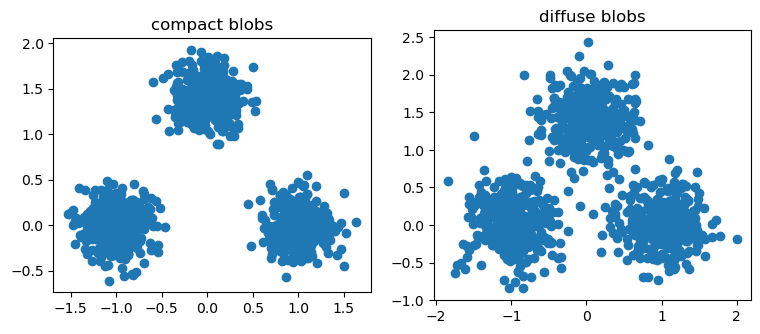

In [2]:
np.random.seed(0)
centers = [(-1.0, 0.0), (1.0, 0.0), (0.0, 1.4)]
X = np.asarray(make_blobs(n_samples=1000, centers=centers, cluster_std=0.2, random_state=0)[0])
Y = np.asarray(make_blobs(n_samples=1000, centers=centers, cluster_std=0.3, random_state=1)[0])

fig, (a, b) = plt.subplots(1, 2, figsize=(9, 4))
a.scatter(*X.T)
a.set_aspect(1)
a.set_title("compact blobs")

b.scatter(*Y.T)
b.set_aspect(1)
b.set_title("diffuse blobs")
plt.show()

Build the same Delaunay core bifiltrations,
[one-critical presentations](../ops/multicritical_free_implicit_resolution.ipynb),
and normalized box used there. The fibered-barcode functions can slice these
[minimal presentations](../ops/minimal_presentations_resolutions.ipynb)
directly.

In [3]:
ks = np.unique(np.linspace(1, min(len(X), len(Y)) // 2, num=200, dtype=int)).tolist()
beta = 0.5

left = mp.filtrations.CoreDelaunay(
    points=X,
    beta=beta,
    ks=ks,
)
right = mp.filtrations.CoreDelaunay(
    points=Y,
    beta=beta,
    ks=ks,
)

degree = 0
left_oc = mp.ops.one_criticalify(left, degree=degree)
right_oc = mp.ops.one_criticalify(right, degree=degree)


def renormalize_slicer(slicer, box):
    box = np.asarray(box, dtype=float)
    scale = box[1] - box[0]
    scale[scale == 0] = 1
    filtrations = (np.asarray(slicer.get_filtrations(), dtype=float) - box[0]) / scale
    out = mp.Slicer(slicer, return_type_only=True)(
        slicer.get_boundaries(),
        slicer.get_dimensions(),
        filtrations,
    )
    out._mark_minpres(slicer.minpres_degree, is_minres=slicer.is_minres)
    return out


box = mp.grids.compute_bounding_box_from_iterable([left_oc, right_oc])
left_oc = renormalize_slicer(left_oc, box)
right_oc = renormalize_slicer(right_oc, box)
box = np.asarray([[0, 0], [1, 1]], dtype=float)

Draw the same deterministic positive-slope lines. Calling
`fibered_barcode(module, basepoint, direction, degree=degree)` returns the
ordinary barcode of one sliced line; `fibered_barcodes` computes the same thing
for all sampled lines. By default `min_persistence=0` removes zero-length
intervals with a strict persistence filter; pass a negative value to keep them.

In [4]:
num_lines = 10
min_persistence = 0.0
rng = np.random.default_rng(1)
line_basepoints = rng.uniform(low=box[0], high=box[1], size=(num_lines, 2))
line_directions = rng.uniform(low=0.05, high=1, size=(num_lines, 2))
line_directions /= line_directions.max(axis=1, keepdims=True)

single_barcode = mpi.fibered_barcode(
    left_oc,
    basepoint=line_basepoints[0],
    direction=line_directions[0],
    degree=degree,
    min_persistence=min_persistence,
)
many_barcodes = mpi.fibered_barcodes(
    left_oc,
    basepoints=line_basepoints,
    directions=line_directions,
    degree=degree,
    min_persistence=min_persistence,
)
right_many_barcodes = mpi.fibered_barcodes(
    right_oc,
    basepoints=line_basepoints,
    directions=line_directions,
    degree=degree,
    min_persistence=min_persistence,
)

To check the wrapper, compute the same line restriction manually: for each
simplex grade $a$, its scalar grade on the line $\ell(t)=b+tv$ is

$$
t(a)=\max_i \frac{a_i-b_i}{v_i}.
$$

Ordinary persistence on these scalar grades is exactly the fibered barcode.

In [5]:
def manual_fibered_barcode(slicer, basepoint, direction, degree):
    grades = np.asarray(slicer.get_filtrations(), dtype=float)
    line_filtration = np.max((grades - basepoint) / direction, axis=1)
    barcode = slicer.compute_persistence(line_filtration)[degree]
    barcode = np.asarray(barcode).reshape(-1, 2)
    return barcode[barcode[:, 1] - barcode[:, 0] > min_persistence]


manual_single = manual_fibered_barcode(
    left_oc,
    line_basepoints[0],
    line_directions[0],
    degree,
)
np.testing.assert_allclose(
    np.asarray(single_barcode).reshape(-1, 2),
    manual_single,
    rtol=0,
    atol=0,
    equal_nan=True,
)

for slicer, barcodes in ((left_oc, many_barcodes), (right_oc, right_many_barcodes)):
    manual_many = tuple(
        manual_fibered_barcode(slicer, basepoint, direction, degree)
        for basepoint, direction in zip(line_basepoints, line_directions, strict=True)
    )
    for barcode, manual_barcode in zip(barcodes, manual_many, strict=True):
        np.testing.assert_allclose(
            np.asarray(barcode).reshape(-1, 2),
            manual_barcode,
            rtol=0,
            atol=0,
            equal_nan=True,
        )

manual_single[:5], np.asarray(single_barcode).reshape(-1, 2)[:5]

(array([[-0.39875677, -0.39757377],
        [-0.39742741, -0.39647345],
        [-0.39757377, -0.39619209],
        [-0.39505951, -0.39437109],
        [-0.3956686 , -0.39437109]]),
 array([[-0.39875677, -0.39757377],
        [-0.39742741, -0.39647345],
        [-0.39757377, -0.39619209],
        [-0.39505951, -0.39437109],
        [-0.3956686 , -0.39437109]]))

The line segments below are the visible parts of the same filtered barcodes,
plotted on top of the module approximations as in the matching-distance
notebook. We clip intervals to the normalized plotting box.

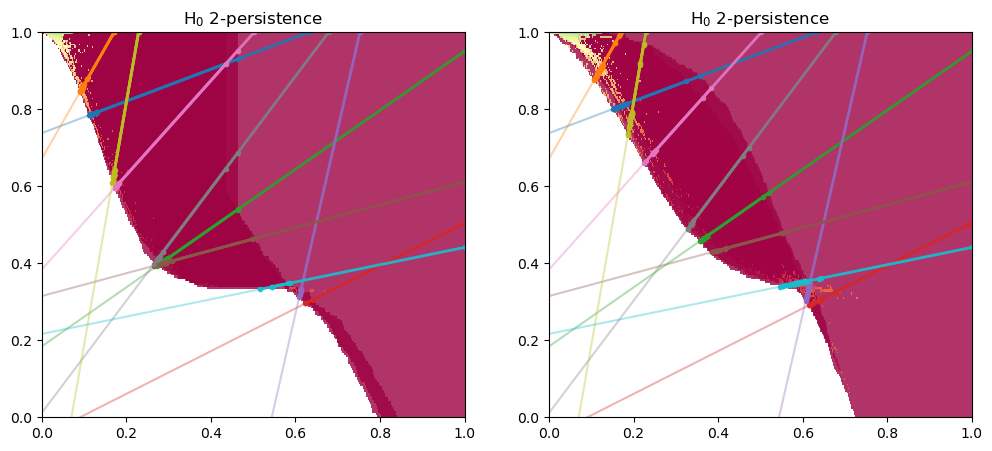

In [6]:
left_mma = mp.module_approximation(
    left_oc,
)
right_mma = mp.module_approximation(
    right_oc,
)


def visible_segment(bar, basepoint, direction):
    line_enter = np.max((box[0] - basepoint) / direction)
    line_exit = np.min((box[1] - basepoint) / direction)
    birth, death = bar
    clipped_birth = max(birth, line_enter)
    clipped_death = min(death, line_exit) if np.isfinite(death) else line_exit
    if clipped_death <= clipped_birth:
        return None
    return basepoint[None] + direction[None] * np.array([clipped_birth, clipped_death])[:, None]


def draw_barcode_slices(ax, slicer):
    alpha = 0.9
    colors = plt.get_cmap("tab10")(np.linspace(0, 1, len(line_basepoints)))
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.set_autoscale_on(False)
    for basepoint, direction, color in zip(line_basepoints, line_directions, colors, strict=True):
        ax.axline(basepoint, slope=direction[1] / direction[0], color=color, alpha=0.35, clip_on=True)
        bars = np.asarray(
            mpi.fibered_barcode(
                slicer,
                basepoint=basepoint,
                direction=direction,
                degree=degree,
                min_persistence=min_persistence,
            )
        ).reshape(-1, 2)
        for bar in bars:
            segment = visible_segment(bar, basepoint, direction)
            if segment is not None:
                ax.plot(segment[:, 0], segment[:, 1], "o-", color=color, lw=2, ms=3, alpha=alpha, clip_on=True)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)


fig, (a, b) = plt.subplots(1, 2, figsize=(12, 5))
plt.sca(a)
left_mma.plot(degree=degree, box=box)
draw_barcode_slices(a, left_oc)

plt.sca(b)
right_mma.plot(degree=degree, box=box)
draw_barcode_slices(b, right_oc)
plt.show()